# Stage 0 — Frozen DINOv2 Embedding QC

Thin notebook: it only **imports**, **calls** `src/`, and **displays**. All
Excel/label logic lives in `src/data.py`; all model/embedding logic in
`src/embeddings.py`. Output: `outputs/analysis/qc_embedding_report.csv`.

Fill in the `EDIT-ME` paths in `config.yaml` before running.

**Input set:** Stage-02 processed 518×518 figures (`paths.processing_manifest_glob`); the model processor is overridden to `analysis.input_size` so DINOv2 actually sees 518px (37×37 patches).


In [10]:
import sys
from pathlib import Path

# Locate the folder root (the dir containing config.yaml) and make src importable.
ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import data, embeddings

cfg = load_config()
print('model   :', cfg['analysis']['model'])
print('layers  :', cfg['analysis']['layers'])
print('pooling :', cfg['analysis']['pooling'])
print('device  :', cfg['analysis']['device'])
print('output  :', cfg['paths']['output_dir'])

model   : facebook/dinov2-large
layers  : [18, 22, 24]
pooling : ['cls', 'mean_patch']
device  : cuda:1
output  : /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_1639_518


In [11]:
OUT0 = Path(cfg['paths']['output_dir']) / 'stage0'
OUT0.mkdir(parents=True, exist_ok=True)


In [12]:
# Discover figures from the Stage-02 processing manifests (518px, padded,
# rotation applied — written by Patent-Labelling-Tools' 02_processing).
# scope="all": every approved processed figure, not just each
# architecture's canonical main image (that's scope="main").
# dedupe_architectures=True: when a patent is a labelled duplicate
# (T1 duplicateId, any type) of another, only the chain's ORIGINAL
# patent's figures are kept — the same design filed under N patents
# contributes its figures once, not N times.
figures = data.list_figures_manifest(cfg, scope="all", dedupe_architectures=True)
figures.head()


[list_figures_manifest] dedupe_architectures: dropped 41 figure(s) belonging to 22 duplicate patent(s) (kept each chain's original)
[list_figures_manifest] 2 manifest(s), scope=all: 488 figures across 198 patents (243 mains)


,figure_id,patent_id,figure_type,path,arch,is_main,bg_sty,bg_col,ac_sty,ac_col
0,CN105730692A_arch1_main.png,CN105730692A,main,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...,1,True,Solid Fill,White,Line Drawing,B/W (Monochrome)
1,CN105730692A_arch1.png,CN105730692A,other,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...,1,False,Solid Fill,White,Line Drawing,B/W (Monochrome)
2,CN105923154A_arch1_main.png,CN105923154A,main,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...,1,True,Solid Fill,White,Line Drawing,B/W (Monochrome)
3,CN106043685A_arch1_main.png,CN106043685A,main,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...,1,True,Solid Fill,White,Line Drawing,B/W (Monochrome)
4,CN106585976A_arch1.png,CN106585976A,other,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...,1,False,Solid Fill,White,Line Drawing,B/W (Monochrome)


In [13]:
# Optional: label coverage sanity check (skipped cleanly if labels not yet configured).
try:
    labels = data.load_labels(cfg)
    have = figures['patent_id'].isin(labels.index)
    print(f'labelled patents in sheet : {len(labels)}')
    print(f'figures whose patent_id is in the sheet : {int(have.sum())} / {len(figures)}')
except Exception as e:
    print('label load skipped:', type(e).__name__, '-', e)

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


labelled patents in sheet : 1639
figures whose patent_id is in the sheet : 488 / 488


In [14]:
# Compute embeddings (or reload if already on disk).
emb_dir = Path(cfg['paths']['output_dir']) / 'embeddings'
if (emb_dir / 'metadata.parquet').exists():
    print('reloading existing embeddings from', emb_dir)
    result = embeddings.load_embeddings(cfg)
else:
    devices = cfg['analysis'].get('devices') or [cfg['analysis']['device']]
    result = embeddings.compute_embeddings_multi_gpu(figures, cfg, devices)
    embeddings.save_embeddings(result, cfg)

print('arrays:', sorted(result['arrays'].keys()))

[compute_embeddings_multi_gpu] splitting 488 figures across ['cuda:0', 'cuda:1']: [244, 244]
[load_model] processor overridden to 518x518 (37x37 patches/side)


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[load_model] detected architecture:
                model_name: facebook/dinov2-large
                   variant: base
         num_hidden_layers: 24
                hidden_dim: 1024
       num_register_tokens: 0
                  n_prefix: 1
                    device: cuda:1
    hidden_states length per forward = 25 (index 0 = embeddings, index i = block i output)



embedding:   0%|          | 0/16 [00:00<?, ?batch/s]

[load_model] processor overridden to 518x518 (37x37 patches/side)


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

[load_model] detected architecture:
                model_name: facebook/dinov2-large
                   variant: base
         num_hidden_layers: 24
                hidden_dim: 1024
       num_register_tokens: 0
                  n_prefix: 1
                    device: cuda:0
    hidden_states length per forward = 25 (index 0 = embeddings, index i = block i output)



embedding: 100%|██████████| 16/16 [00:28<00:00,  1.79s/batch]

[save_embeddings] wrote 6 arrays + metadata to /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_1639_518/embeddings
arrays: [(18, 'cls'), (18, 'mean_patch'), (22, 'cls'), (22, 'mean_patch'), (24, 'cls'), (24, 'mean_patch')]


In [15]:
# Build + persist the Stage-0 QC report.
report = embeddings.qc_report(result, seed=cfg['analysis']['seed'])

csv_path = OUT0 / 'qc_embedding_report.csv'
csv_path.parent.mkdir(parents=True, exist_ok=True)
report.to_csv(csv_path, index=False)
print('wrote', csv_path)

_fmt = {c: '{:.4f}' for c in ['cos_mean', 'cos_std', 'cos_p05', 'cos_p50', 'cos_p95',
                                'dim_var_mean', 'dim_var_min', 'dim_var_max']}

def _highlight_best_worst(s):
    best  = s == s.max()
    worst = s == s.min()
    return ['background-color: #c6efce' if b else
            'background-color: #ffc7ce' if w else ''
            for b, w in zip(best, worst)]

(report
    .style
    .format(_fmt)
    .apply(_highlight_best_worst, subset=['cos_mean'])
    .set_caption('Stage-0 QC Report  (green = best cos_mean, red = worst)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',
         'props': [('background-color', '#4472c4'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '4px 10px')]},
    ])
)


wrote /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_1639_518/stage0/qc_embedding_report.csv


,layer,pooling,variant,n_layers,hidden_dim,num_register_tokens,n_prefix,emb_dim,n_figures,n_patents,fig_per_patent_min,fig_per_patent_median,fig_per_patent_max,nan_count,inf_count,all_zero_count,exact_duplicate_count,dim_var_mean,dim_var_min,dim_var_max,near_dead_dims,cos_mean,cos_std,cos_p05,cos_p50,cos_p95
0,18,cls,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0000,0.0000,0.0002,0,0.9746,0.0123,0.9477,0.9772,0.9890
1,18,mean_patch,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0001,0.0000,0.0017,0,0.9383,0.0355,0.8797,0.9453,0.9776
2,22,cls,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0001,0.0000,0.0012,0,0.9005,0.0324,0.8392,0.9053,0.9450
3,22,mean_patch,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0001,0.0000,0.0010,0,0.9366,0.0293,0.8852,0.9408,0.9745
4,24,cls,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0006,0.0000,0.0042,0,0.4185,0.1264,0.2229,0.4124,0.6376
5,24,mean_patch,base,24,1024,0,1,1024,488,198,1,2.000000,10,0,0,0,0,0.0001,0.0000,0.0025,0,0.8897,0.0494,0.8122,0.8966,0.9505


## Visual inspection only — not a metric

The two histograms below are for eyeballing distribution shape only. They are
**not** Stage-0 pass/fail criteria — the numeric gate is in the report table.

visualizing layer/pooling: (18, 'cls') shape (488, 1024)


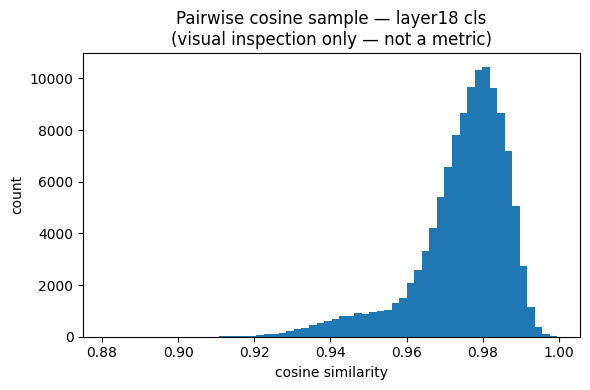

In [16]:
# Pick a representative (layer, pooling) to visualize.
key = sorted(result['arrays'].keys())[0]
arr = result['arrays'][key]
print('visualizing layer/pooling:', key, 'shape', arr.shape)

sims = embeddings._pairwise_cosine_sample(arr, embeddings.PAIRWISE_SAMPLE_SIZE, cfg['analysis']['seed'])
plt.figure(figsize=(6, 4))
plt.hist(sims, bins=60)
plt.title(f'Pairwise cosine sample — layer{key[0]} {key[1]}\n(visual inspection only — not a metric)')
plt.xlabel('cosine similarity'); plt.ylabel('count')
plt.tight_layout(); plt.show()

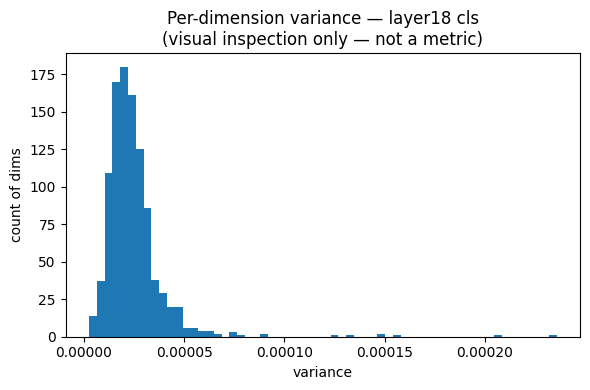

In [17]:
dim_var = arr.var(axis=0)
plt.figure(figsize=(6, 4))
plt.hist(dim_var, bins=60)
plt.title(f'Per-dimension variance — layer{key[0]} {key[1]}\n(visual inspection only — not a metric)')
plt.xlabel('variance'); plt.ylabel('count of dims')
plt.tight_layout(); plt.show()

In [18]:
# Stage-0 gate.
passed = embeddings.qc_pass_fail(report)
print('=' * 48)
print('STAGE 0:', 'PASS ✅' if passed else 'FAIL ❌')
print('=' * 48)
if not passed:
    bad = report[(report['nan_count'] > 0) | (report['inf_count'] > 0) | (report['all_zero_count'] > 0)]
    print('offending (layer, pooling) rows:')
    display(bad[['layer', 'pooling', 'nan_count', 'inf_count', 'all_zero_count']])

STAGE 0: PASS ✅
